In [1]:
from lib import epl 
from lib import OSN
from lib import readout
from lib import plots
import numpy as np
import pickle 
import random #remember to do this in class
from sklearn import datasets
import matplotlib.pyplot as plt
from preprocess import preprocessing as pre
import epl.src.computeResults as compResults
from numpy.matlib import repmat
#import epl.src.multi_pattern_learning.epl_multi_pattern_learning 
#from epl.src.multi_pattern_learning.epl_multi_pattern_learning import EPLMultiPatternLearning


In [2]:
# load the digits dataset which consists of 8X8 images of digits
digits = datasets.load_digits()
images = digits.images
targets = digits.target
# create a map of {digt->list of images of the digits}
image_dict = {n : [] for n in range(10)}
for t, img in zip(targets, images):
    image_dict[t].append(img)

In [3]:

numPatterns = 6
#randomly choose 6 digits
digits = [0, 2, 4, 5, 7, 9]


In [4]:
#CAN STAY IN CODE

#define utility functions
#create the training dataset by choosing the appropriate images of the digts to be learned
def get_training_data(digits, fourX=True, idx=0):
    train_data = []
    for digit in digits:
        training_image = image_dict[digit][idx]
        print(training_image)
        training_image = np.ndarray.astype(training_image, int)
        if fourX: training_image = (training_image//4)*4
        training_image = np.ndarray.flatten(training_image).tolist()
        print(training_image)
        train_data.append(training_image)
    return train_data

In [5]:
# generate the training data
train_data = np.array(get_training_data(digits=digits))

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
[0, 0, 4, 12, 8, 0, 0, 0, 0, 0, 12, 12, 8, 12, 4, 0, 0, 0, 12, 0, 0, 8, 8, 0, 0, 4, 12, 0, 0, 8, 8, 0, 0, 4, 8, 0, 0, 8, 8, 0, 0, 4, 8, 0, 0, 12, 4, 0, 0, 0, 12, 4, 8, 12, 0, 0, 0, 0, 4, 12, 8, 0, 0, 0]
[[ 0.  0.  0.  4. 15. 12.  0.  0.]
 [ 0.  0.  3. 16. 15. 14.  0.  0.]
 [ 0.  0.  8. 13.  8. 16.  0.  0.]
 [ 0.  0.  1.  6. 15. 11.  0.  0.]
 [ 0.  1.  8. 13. 15.  1.  0.  0.]
 [ 0.  9. 16. 16.  5.  0.  0.  0.]
 [ 0.  3. 13. 16. 16. 11.  5.  0.]
 [ 0.  0.  0.  3. 11. 16.  9.  0.]]
[0, 0, 0, 4, 12, 12, 0, 0, 0, 0, 0, 16, 12, 12, 0, 0, 0, 0, 8, 12, 8, 16, 0, 0, 0, 0, 0, 4, 12, 8, 0, 0, 0, 0, 8, 12, 12, 0, 0, 0, 0, 8, 16, 16, 4, 0, 0, 0, 0, 0, 12, 16, 16, 8, 4, 0, 0, 0, 0, 0, 8, 16, 8, 0]
[[ 0.  0.  0.  1. 11.  0. 

In [6]:
def generateTestingData(trainingData, occlusionPercent, numTestSamples,
                        sensorDynamicRange=16):  #15 to 16
    """ generate synthetic testing data for EPL network"""
    data = trainingData
    p = occlusionPercent
    n = numTestSamples
    occludedData = []
    nsensors = len(data[0])

    for i in range(0, len(data)):
        ndim = len(data[i])  # dimension of data
        for j in range(0, n):
            occludedData.append([])
            affected_ids = random.sample(range(ndim), int(p * ndim))
            for k in range(0, ndim):
                if k in affected_ids:
                    occludedData[i * n + j].append(
                        random.randint(0, sensorDynamicRange))
                else:
                    occludedData[i * n + j].append(data[i][k])
    return occludedData
numTestSamples = 5
occlusionPercent = 0.2 # randomly perturb only 20% of the image pixels
test_data = np.array(generateTestingData(trainingData=train_data,
                                occlusionPercent=occlusionPercent,
                                numTestSamples=numTestSamples))

In [7]:

# display the images of the patterns (digits) to be learned
def plot_images(digits, data, title, nrows=2, ncols=3):
    fig, axs = plt.subplots(nrows, ncols, figsize=(8, nrows*4),
                        subplot_kw={'xticks': [], 'yticks': []})
    for i, ax in enumerate(axs.flat):
        img = data[i]
        img = np.reshape(img, (8,8))
        ax.imshow(img, interpolation=None, cmap='viridis')
        ax.set_title(str(digits[i]))
    plt.tight_layout()
    fig.suptitle(title, fontsize=16)
    plt.show()

In [8]:
#useless as of now
def plot_images_rasters(digits, data, title, nrows=2, ncols=3):
    fig, axs = plt.subplots(nrows, ncols, figsize=(8, nrows*4),
                        subplot_kw={'xticks': [], 'yticks': []})
    for i, ax in enumerate(axs.flat):
        img = data[i]
        img = np.reshape(img, (8,8))
        ax.imshow(img, interpolation=None, cmap='viridis')
        ax.set_title(str(digits[i]))
    plt.tight_layout()
    fig.suptitle(title, fontsize=16)
    plt.show()

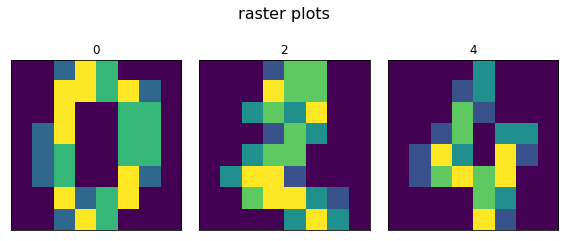

NameError: name 'testOdors' is not defined

In [9]:
plot_images(digits[:3],train_data[:3], title="raster plots", nrows=1)
for i in range(0,3):
    trainingOdors = [testOdors[i]]
    gammaCode = epl.gammaCode
    pre.plotFigure3b(epl.gammaCode, nGamma=5,figsize = (3,12))

plot_images(digits[3:],train_data[3:], title="raster plots", nrows=1)
for i in range(3,6):
    trainingOdors = [testOdors[i]]
    gammaCode = epl.gammaCode
    pre.plotFigure3b(epl.gammaCode, nGamma=5,figsize = (3,12))

In [11]:
from lib import epl
gammaCode = epl.gammaCode
nGamma=1
plt.figure(1, figsize=(3, 12))
#nGamma = 5; 
nMCs = 64; 
for i in range(0, nGamma):
    s = int('51'+str(i+1))
    plt.subplot(s);
    for j in range(0, nMCs):
        #Learned Toluene
        gammaID = 1*nGamma + 9; 
        if gammaCode[gammaID][j] != 0:
            spikeTime = 20 - gammaCode[gammaID][j]; 
            plt.scatter(spikeTime, j, s= 8, marker = 'o', color = 'w', edgecolor='k')
        #Occluded Toluene
        testSample = 0; 
        gammaID = 10 + nGamma*testSample + i; 
        if gammaCode[gammaID][j] != 0:
            spikeTime = 20 - gammaCode[gammaID][j]; 
            plt.scatter(spikeTime, j, s= 2, marker = 'o', color = (0, 0, 1, 0.5)); 
        plt.ylim([-2,71])
        offset = 40*i; 
        plt.xticks([0, 4, 8, 12, 16, 20], [offset+0, offset+4, offset+8, offset+12, offset+16, offset+20]); 
        plt.yticks([15, 30, 45, 60]); 
        


AttributeError: 'module' object has no attribute 'gammaCode'

In [19]:
raster_data = []
testOdors = trainingOdors
for i in range(0,1):
    trainingOdors = [testOdors[i]]
    from lib import epl 
    nOdors = len(trainingOdors); 
    nTestPerOdor = len(testOdors)/nOdors;  
    #Network initialization
    nMCs = len(trainingOdors[0]); 
    GCsPerNeurogenesis = 5; 
    nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
    epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

    #Sniff
    def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
        sensorInput = OSN.OSN_encoding(odor); 
        for j in range(0, nGammaPerOdor):
            for k in range(0, gPeriod): 
                epl.update(sensorInput, learn_flag=learn_flag);
                pass; 
        epl.reset(); 

    #Training
    for i in range(0, len(trainingOdors)):
        #print("Training odor " + str(i+1)) 
        sniff(trainingOdors[i], learn_flag=1);
        epl.GClayer.invokeNeurogenesis();
        sniff(trainingOdors[i], learn_flag=0);

    #Testing
    for i in range(0, len(testOdors)):
        sniff(testOdors[i], learn_flag=0); 
        #if(i==len(testOdors)-1):
            #print(str(i+1) + " odors tested"); 

    #Readout
    sMatrix = readout.readout(epl.gammaCode, nOdors, nTestPerOdor)  
    
    raster_data.append(epl.gammaCode)
    pre.plotFigure3b(epl.gammaCode, nGamma = 5); 


TypeError: plotFigure3b() takes at least 2 arguments (2 given)

In [20]:
nOdors

1

In [ ]:

plot_images(digits, train_data, title="Digits to Learn")


In [ ]:
test_digits = repmat(digits, 5,1).T.flatten()

In [ ]:
plot_images(test_digits, test_data, title="Digits to Learn",nrows=10, ncols=3)
#take a look at plot images to show more than six images

In [ ]:
#visualize the test data by displaying the 3rd test sample for each pattern
test_data_subset = []
sampleIdx=3
for patternIdx in range(numPatterns):
    idx = patternIdx * numTestSamples + sampleIdx
    test_data_subset.append(test_data[idx])

#plot the 3rd test sample for each pattern
plot_images(digits, test_data_subset, title="Noisy samples of the learned digits")

In [15]:

scale = 15.0
train_data -= train_data.min()
train_data = train_data*(scale/train_data.max())
trainingOdors = train_data.astype(np.int64)




In [16]:
test_data -= test_data.min()
test_data = test_data* scale/test_data.max()
testOdors = test_data.astype(np.int64)

In [17]:
testOdors = trainingOdors

In [18]:
from lib import epl 

nOdors = len(trainingOdors); 
nTestPerOdor = len(testOdors)/nOdors;  
print("Number of odors to train = " + str(len(trainingOdors))); 
print("Number of odors to test = " + str(len(testOdors))); 

#Network initialization
nMCs = len(trainingOdors[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
for i in range(0, len(trainingOdors)):
    print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1);
    epl.GClayer.invokeNeurogenesis();
    sniff(trainingOdors[i], learn_flag=0);

#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0); 
    if(i==len(testOdors)-1):
        print(str(i+1) + " odors tested"); 

#Readout
sMatrix = readout.readout(epl.gammaCode, nOdors, nTestPerOdor)  



Number of odors to train = 6
Number of odors to test = 6
Training odor 1
Training odor 2
Training odor 3
Training odor 4
Training odor 5
Training odor 6
6 odors tested


In [ ]:
pre.plotFigure3b(epl.gammaCode, nGamma = 1); 


In [ ]:
compResults.computeResults(5,1,10,nsensors = 64,gammaCode=epl.gammaCode)

In [ ]:

plots.plotFigure3d(sMatrix); 

In [ ]:
pre.plotTrainedtoTarget(sMatrix)

In [ ]:
plt.subplot(int('11'+str(0+1)))

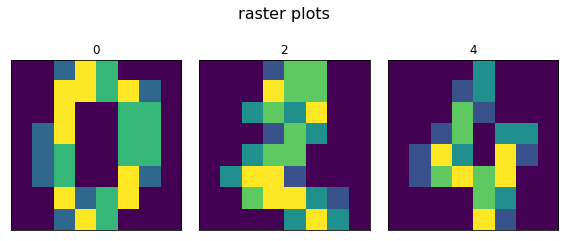

NameError: name 'testOdors' is not defined

In [14]:
for i in range(0,6):
    from lib import epl 
    if i == 0:
        pre.plot_images(digits[:3],train_data[:3], title="raster plots", nrows=1)
    if i == 3:
        pre.plot_images(digits[3:],train_data[3:], title="raster plots", nrows=1)
    
    trainingOdors = [testOdors[i]]
    
    nOdors = len(trainingOdors); 
    nTestPerOdor = len(testOdors)/nOdors;  
    #Network initialization
    nMCs = len(trainingOdors[0]); 
    GCsPerNeurogenesis = 5; 
    nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
    epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

    #Sniff
    def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
        sensorInput = OSN.OSN_encoding(odor); 
        for j in range(0, nGammaPerOdor):
            for k in range(0, gPeriod): 
                epl.update(sensorInput, learn_flag=learn_flag);
                pass; 
        epl.reset(); 

    #Training
    for i in range(0, len(trainingOdors)):
        #print("Training odor " + str(i+1)) 
        sniff(trainingOdors[i], learn_flag=1);
        epl.GClayer.invokeNeurogenesis();
        #sniff(trainingOdors[i], learn_flag=0);

    #Testing
    for i in range(0, len(testOdors)):
        sniff(testOdors[i], learn_flag=0); 